# Analyse des Avis et Alertes ANSSI avec Enrichissement des CVE

**TD Final – SUPDEVINCI 2026**

Ce notebook charge les données consolidées (avis/alertes ANSSI + CVE enrichies
via MITRE et EPSS), explore le jeu de données, produit des visualisations, puis
applique et valide un modèle de Machine Learning supervisé et un modèle non
supervisé.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Chargement du fichier CSV produit

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data/vulnerabilites_anssi.csv").exists():
    PROJECT_ROOT = Path.cwd().parent

csv_path = PROJECT_ROOT / "data/vulnerabilites_anssi.csv"
df = pd.read_csv(csv_path, parse_dates=["date_publication"])
df.shape


(227, 15)

In [3]:
df.head(10)

,id_anssi,titre_anssi,type_bulletin,date_publication,cve,cvss_score,base_severity,cwe,cwe_desc,epss_score,lien_anssi,description,editeur,produit,versions_affectees
0,CERTFR-2026-AVI-0632,Multiples vulnérabilités dans les produits Mat...,Avis,"Fri, 22 May 2026 00:00:00 +0000",CVE-2026-6517,6.3,MEDIUM,CWE-522,CWE-522: Insufficiently Protected Credentials,0.00186,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Mattermost Desktop App versions <=6.1 5.5.13.0...,Mattermost,Mattermost,0
1,CERTFR-2026-AVI-0716,Multiples vulnérabilités dans FreeBSD (10 juin...,Avis,"Wed, 10 Jun 2026 00:00:00 +0000",CVE-2026-45257,NaN,Non disponible,Non disponible,Non disponible,NaN,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Non disponible,NaN,NaN,NaN
2,CERTFR-2026-AVI-0716,Multiples vulnérabilités dans FreeBSD (10 juin...,Avis,"Wed, 10 Jun 2026 00:00:00 +0000",CVE-2026-49413,NaN,Non disponible,Non disponible,Non disponible,NaN,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Non disponible,NaN,NaN,NaN
3,CERTFR-2026-AVI-0733,Multiples vulnérabilités dans GitLab (11 juin ...,Avis,"Thu, 11 Jun 2026 00:00:00 +0000",CVE-2026-10087,8.7,HIGH,CWE-79,CWE-79: Improper Neutralization of Input Durin...,0.00427,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,GitLab has remediated an issue in GitLab EE af...,GitLab,GitLab,"17.1, 18.11, 19.0"
4,CERTFR-2026-AVI-0733,Multiples vulnérabilités dans GitLab (11 juin ...,Avis,"Thu, 11 Jun 2026 00:00:00 +0000",CVE-2026-10733,4.3,MEDIUM,CWE-1021,CWE-1021: Improper Restriction of Rendered UI ...,0.00352,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,GitLab has remediated an issue in GitLab CE/EE...,GitLab,GitLab,"17.0, 18.11, 19.0"
5,CERTFR-2026-AVI-0733,Multiples vulnérabilités dans GitLab (11 juin ...,Avis,"Thu, 11 Jun 2026 00:00:00 +0000",CVE-2026-1500,6.5,MEDIUM,CWE-770,CWE-770: Allocation of Resources Without Limit...,0.00545,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,GitLab has remediated an issue in GitLab CE/EE...,GitLab,GitLab,"17.10, 18.11, 19.0"
6,CERTFR-2026-AVI-0733,Multiples vulnérabilités dans GitLab (11 juin ...,Avis,"Thu, 11 Jun 2026 00:00:00 +0000",CVE-2026-3553,3.1,LOW,CWE-863,CWE-863: Incorrect Authorization,0.00308,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,GitLab has remediated an issue in GitLab CE/EE...,GitLab,GitLab,"12.0, 18.11, 19.0"
7,CERTFR-2026-AVI-0733,Multiples vulnérabilités dans GitLab (11 juin ...,Avis,"Thu, 11 Jun 2026 00:00:00 +0000",CVE-2026-6269,5.4,MEDIUM,CWE-863,CWE-863: Incorrect Authorization,0.00302,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,GitLab has remediated an issue in GitLab CE/EE...,GitLab,GitLab,"15.10, 18.11, 19.0"
8,CERTFR-2026-AVI-0733,Multiples vulnérabilités dans GitLab (11 juin ...,Avis,"Thu, 11 Jun 2026 00:00:00 +0000",CVE-2026-6277,4.3,MEDIUM,CWE-863,CWE-863: Incorrect Authorization,0.00311,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,GitLab has remediated an issue in GitLab EE af...,GitLab,GitLab,"13.9, 18.11, 19.0"
9,CERTFR-2026-AVI-0733,Multiples vulnérabilités dans GitLab (11 juin ...,Avis,"Thu, 11 Jun 2026 00:00:00 +0000",CVE-2026-6552,8.7,HIGH,CWE-639,CWE-639: Authorization Bypass Through User-Con...,0.00469,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,GitLab has remediated an issue in GitLab EE af...,GitLab,GitLab,"15.5, 18.11, 19.0"


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_anssi            227 non-null    str    
 1   titre_anssi         227 non-null    str    
 2   type_bulletin       227 non-null    str    
 3   date_publication    227 non-null    str    
 4   cve                 227 non-null    str    
 5   cvss_score          37 non-null     float64
 6   base_severity       39 non-null     str    
 7   cwe                 227 non-null    str    
 8   cwe_desc            227 non-null    str    
 9   epss_score          224 non-null    float64
 10  lien_anssi          227 non-null    str    
 11  description         227 non-null    str    
 12  editeur             224 non-null    str    
 13  produit             224 non-null    str    
 14  versions_affectees  211 non-null    str    
dtypes: float64(2), str(13)
memory usage: 26.7 KB


## 2. Exploration du DataFrame

On regarde la qualité des données (valeurs manquantes, doublons), la
répartition avis/alertes, le nombre de CVE uniques, etc.


In [5]:
print("Nombre de lignes :", len(df))
print("Nombre de bulletins ANSSI uniques :", df["id_anssi"].nunique())
print("Nombre de CVE uniques :", df["cve"].nunique())
print("Nombre d'éditeurs uniques :", df["editeur"].nunique())
print("Nombre de produits uniques :", df["produit"].nunique())


Nombre de lignes : 227
Nombre de bulletins ANSSI uniques : 4
Nombre de CVE uniques : 212
Nombre d'éditeurs uniques : 4
Nombre de produits uniques : 13


In [6]:
df.isna().mean().sort_values(ascending=False).to_frame("taux_valeurs_manquantes")


,taux_valeurs_manquantes
cvss_score,0.837004
base_severity,0.828194
versions_affectees,0.070485
produit,0.013216
editeur,0.013216
epss_score,0.013216
id_anssi,0.000000
date_publication,0.000000
cve,0.000000
titre_anssi,0.000000


In [7]:
df["type_bulletin"].value_counts()


type_bulletin
Avis    227
Name: count, dtype: int64

In [8]:
df["base_severity"].value_counts(dropna=False)


base_severity
NaN               188
MEDIUM             25
HIGH                6
LOW                 6
Non disponible      2
Name: count, dtype: int64

In [9]:
df[["cvss_score", "epss_score"]].describe()


,cvss_score,epss_score
count,37.000000,224.000000
mean,5.170270,0.002467
std,1.898079,0.001052
min,1.100000,0.001030
25%,4.400000,0.001897
50%,4.800000,0.002220
75%,6.100000,0.002650
max,8.700000,0.008250


## 3. Visualisations

### 3.1 Histogramme des scores CVSS

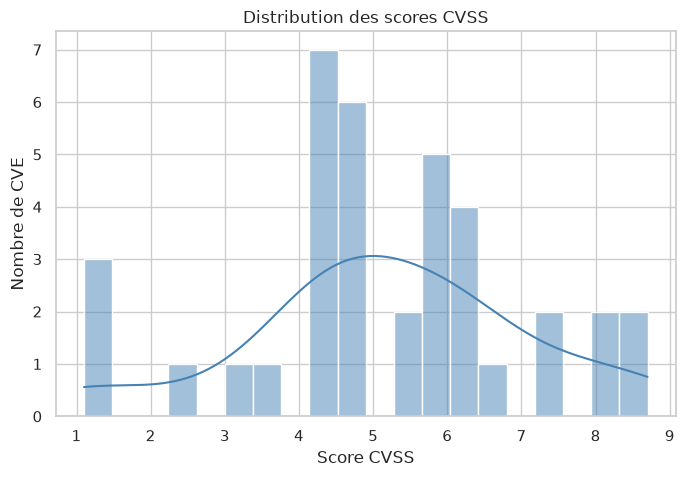

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df["cvss_score"].dropna(), bins=20, kde=True, color="steelblue")
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de CVE")
plt.show()


### 3.2 Répartition par niveau de sévérité (Base Severity)

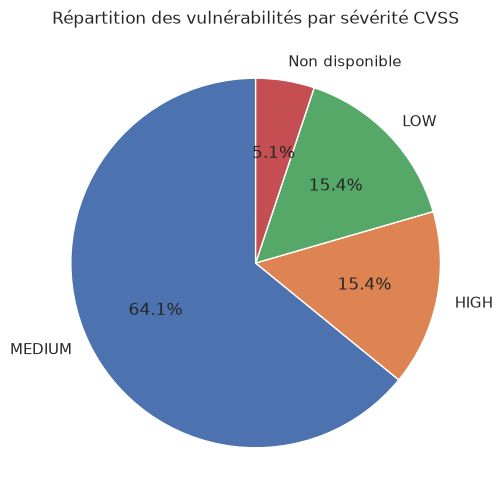

In [11]:
plt.figure(figsize=(6, 6))
df["base_severity"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90)
plt.ylabel("")
plt.title("Répartition des vulnérabilités par sévérité CVSS")
plt.show()


### 3.3 Diagramme circulaire des types de vulnérabilités (CWE)

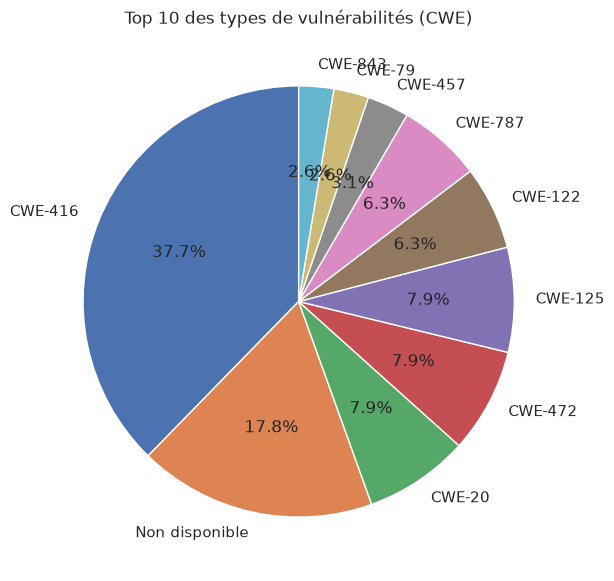

In [12]:
top_cwe = df["cwe"].value_counts().head(10)
plt.figure(figsize=(7, 7))
top_cwe.plot.pie(autopct="%1.1f%%", startangle=90)
plt.ylabel("")
plt.title("Top 10 des types de vulnérabilités (CWE)")
plt.show()


### 3.4 Distribution des scores EPSS (probabilité d'exploitation)

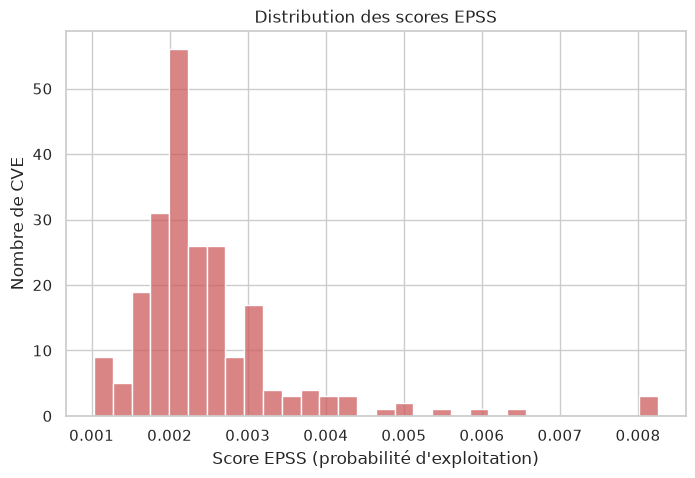

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df["epss_score"].dropna(), bins=30, color="indianred")
plt.title("Distribution des scores EPSS")
plt.xlabel("Score EPSS (probabilité d'exploitation)")
plt.ylabel("Nombre de CVE")
plt.show()


### 3.5 Classement des éditeurs les plus affectés

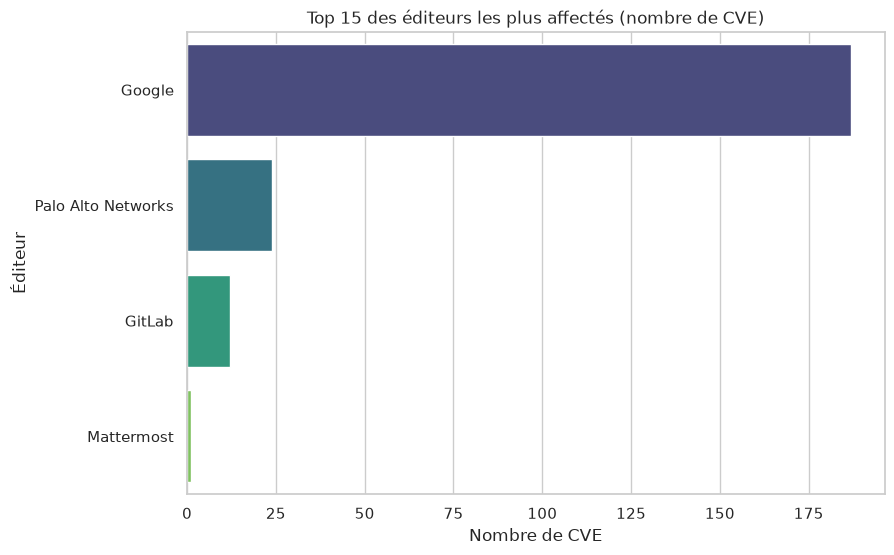

In [14]:
top_vendors = df["editeur"].value_counts().head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=top_vendors.values, y=top_vendors.index, hue=top_vendors.index, palette="viridis", legend=False)
plt.title("Top 15 des éditeurs les plus affectés (nombre de CVE)")
plt.xlabel("Nombre de CVE")
plt.ylabel("Éditeur")
plt.show()


### 3.6 Classement des produits les plus affectés

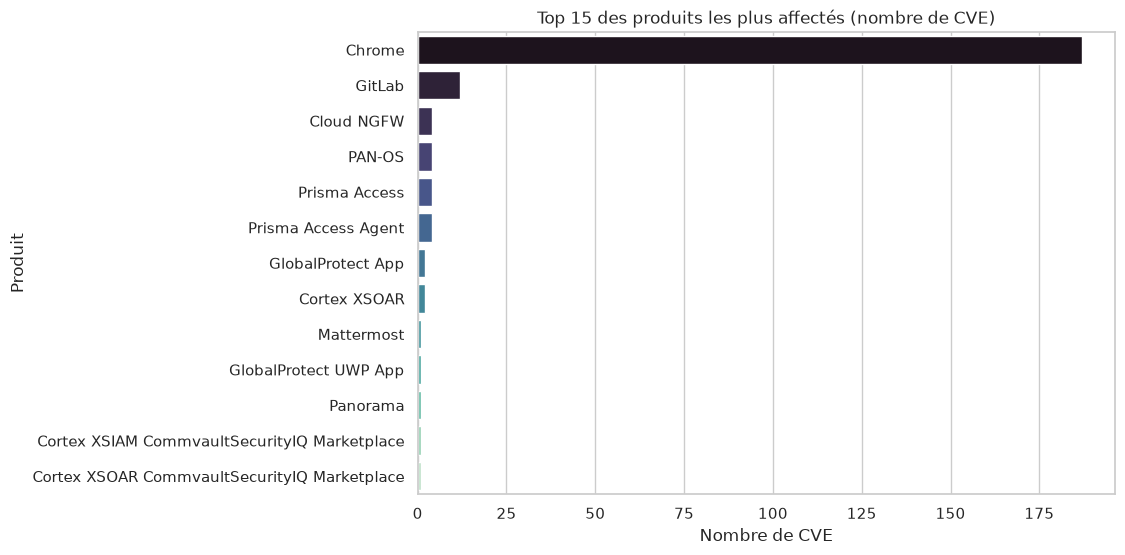

In [15]:
top_products = df["produit"].value_counts().head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette="mako", legend=False)
plt.title("Top 15 des produits les plus affectés (nombre de CVE)")
plt.xlabel("Nombre de CVE")
plt.ylabel("Produit")
plt.show()


### 3.7 Heatmap de corrélation entre CVSS et EPSS

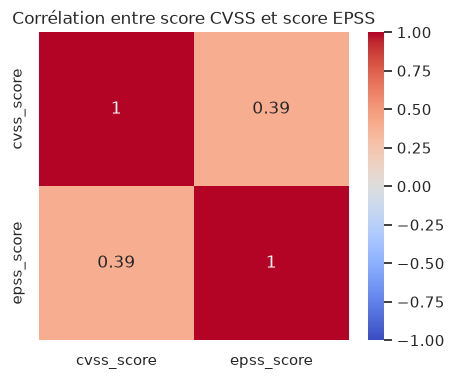

In [16]:
corr = df[["cvss_score", "epss_score"]].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corrélation entre score CVSS et score EPSS")
plt.show()


### 3.8 Nuage de points Score CVSS vs Score EPSS

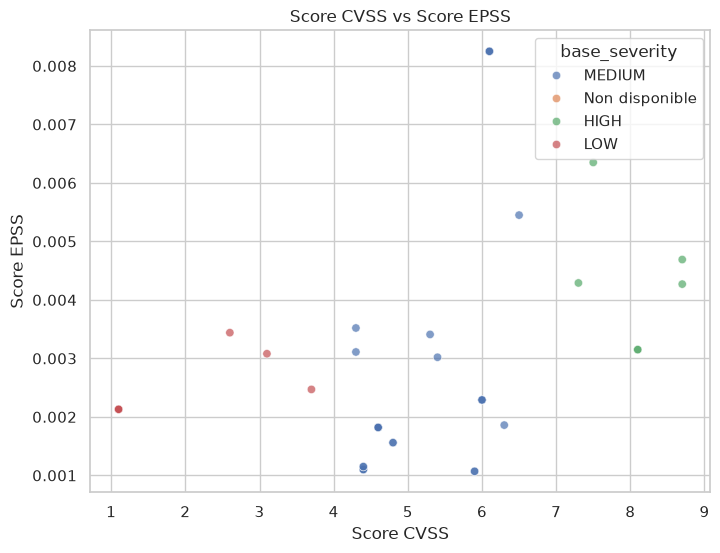

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="cvss_score", y="epss_score", hue="base_severity", alpha=0.7)
plt.title("Score CVSS vs Score EPSS")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.show()


### 3.9 Courbe cumulative des vulnérabilités détectées dans le temps

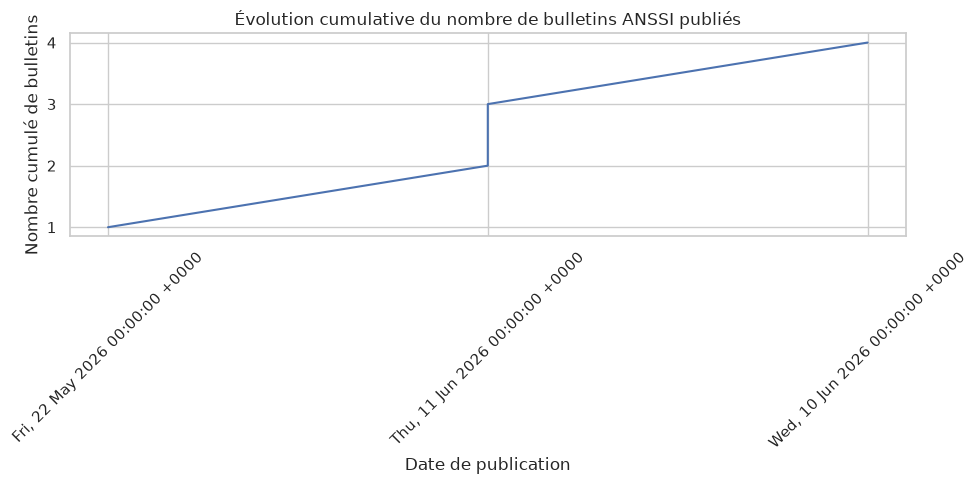

In [18]:
ts = (
    df.dropna(subset=["date_publication"])
    .drop_duplicates("id_anssi")
    .sort_values("date_publication")
)
ts["cumul"] = range(1, len(ts) + 1)

plt.figure(figsize=(10, 5))
plt.plot(ts["date_publication"], ts["cumul"])
plt.title("Évolution cumulative du nombre de bulletins ANSSI publiés")
plt.xlabel("Date de publication")
plt.ylabel("Nombre cumulé de bulletins")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3.10 Boxplot des scores CVSS par éditeur (top 10)

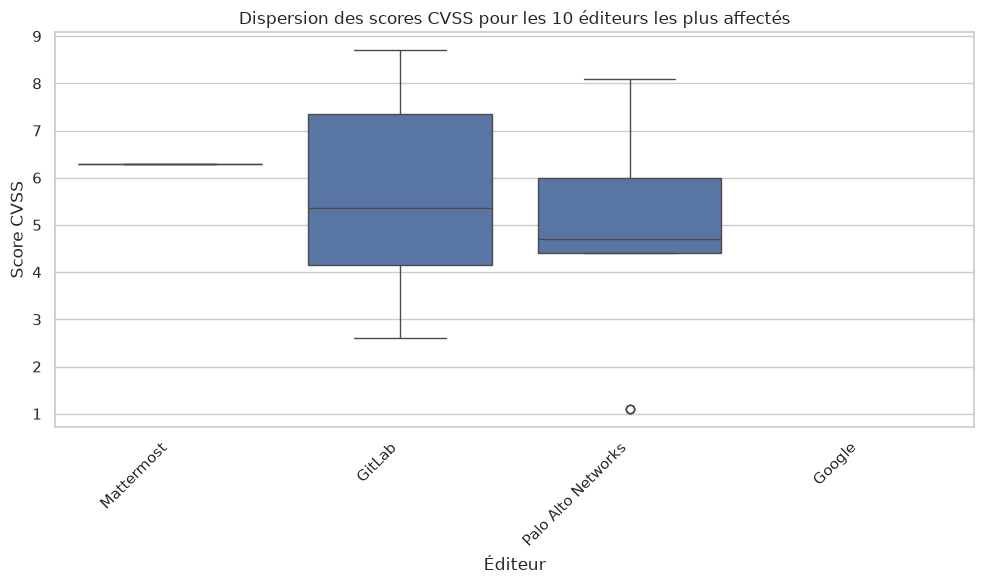

In [19]:
top10_vendors = df["editeur"].value_counts().head(10).index
subset = df[df["editeur"].isin(top10_vendors)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=subset, x="editeur", y="cvss_score")
plt.title("Dispersion des scores CVSS pour les 10 éditeurs les plus affectés")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Éditeur")
plt.ylabel("Score CVSS")
plt.tight_layout()
plt.show()


### 3.11 Nombre de vulnérabilités par éditeur, par type de bulletin

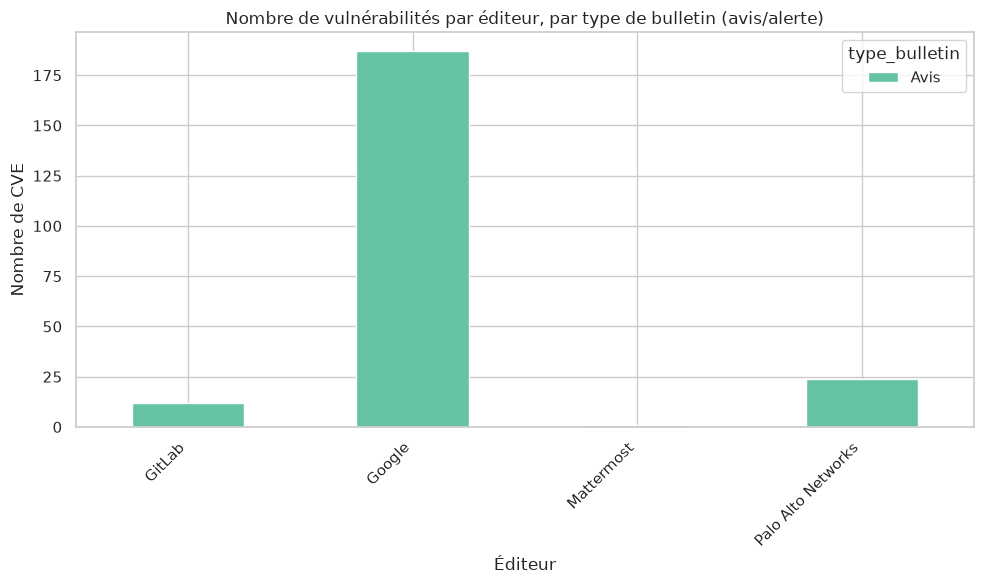

In [20]:
cross = df[df["editeur"].isin(top10_vendors)].groupby(["editeur", "type_bulletin"]).size().unstack(fill_value=0)
cross.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="Set2")
plt.title("Nombre de vulnérabilités par éditeur, par type de bulletin (avis/alerte)")
plt.xlabel("Éditeur")
plt.ylabel("Nombre de CVE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 4. Préparation des données pour le Machine Learning

On construit un jeu de features numériques/catégorielles à partir des
colonnes enrichies (CVSS, CWE, EPSS, éditeur...). On élimine les lignes sans
score CVSS ou EPSS (CVE non trouvées dans MITRE/FIRST), nécessaires pour
les deux approches ML.


In [21]:
ml_df = df.dropna(subset=["cvss_score", "epss_score", "cwe"]).copy()
ml_df = ml_df.drop_duplicates(subset=["cve"])
print("Nombre de CVE exploitables pour le ML :", len(ml_df))
ml_df[["cve", "cvss_score", "base_severity", "cwe", "epss_score"]].head()


Nombre de CVE exploitables pour le ML : 22


,cve,cvss_score,base_severity,cwe,epss_score
0,CVE-2026-6517,6.3,MEDIUM,CWE-522,0.00186
3,CVE-2026-10087,8.7,HIGH,CWE-79,0.00427
4,CVE-2026-10733,4.3,MEDIUM,CWE-1021,0.00352
5,CVE-2026-1500,6.5,MEDIUM,CWE-770,0.00545
6,CVE-2026-3553,3.1,LOW,CWE-863,0.00308


## 5. Modèle non supervisé : Clustering des vulnérabilités

Objectif : regrouper les CVE en clusters homogènes à partir de leur score
CVSS et de leur score EPSS, afin d'identifier des profils de risque
(ex : faible gravité/faible exploitation, forte gravité/forte exploitation...).

On utilise **KMeans**, avec une normalisation préalable des features et une
recherche du nombre de clusters via le score de silhouette.


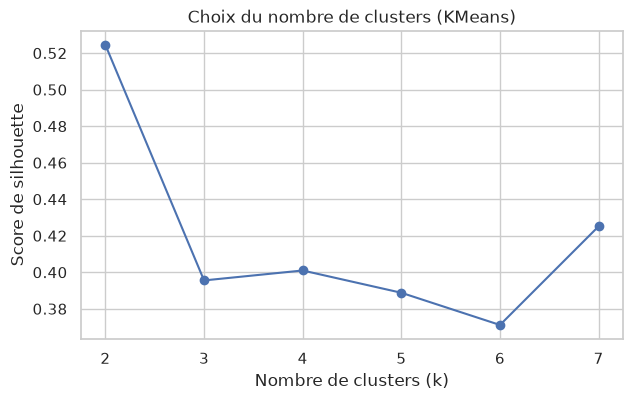

Meilleur k : 2 - silhouette : 0.5244577341851028


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_cluster = ml_df[["cvss_score", "epss_score"]].values
X_scaled = StandardScaler().fit_transform(X_cluster)

scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

plt.figure(figsize=(7, 4))
plt.plot(list(scores.keys()), list(scores.values()), marker="o")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de silhouette")
plt.title("Choix du nombre de clusters (KMeans)")
plt.show()

best_k = max(scores, key=scores.get)
print("Meilleur k :", best_k, "- silhouette :", scores[best_k])


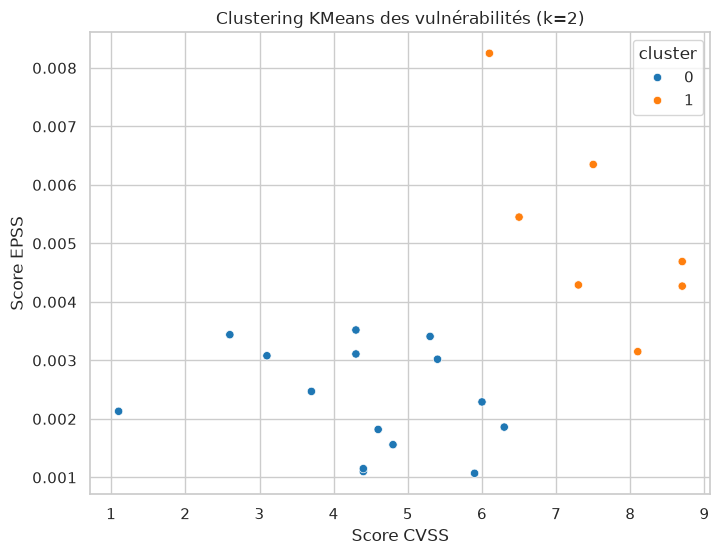

,cvss_score,epss_score
cluster,,
0,4.413333,0.002335
1,7.557143,0.005207


In [23]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
ml_df["cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=ml_df, x="cvss_score", y="epss_score", hue="cluster", palette="tab10")
plt.title(f"Clustering KMeans des vulnérabilités (k={best_k})")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.show()

ml_df.groupby("cluster")[["cvss_score", "epss_score"]].mean()


**Validation du modèle non supervisé** : le score de silhouette (calculé
ci-dessus pour plusieurs valeurs de k) mesure la cohérence interne des
clusters (entre -1 et 1, plus il est proche de 1 meilleure est la séparation).
Le k retenu est celui qui maximise ce score.


## 6. Modèle supervisé : Prédiction de la sévérité (Base Severity)

Objectif : prédire la catégorie de sévérité CVSS (`LOW`, `MEDIUM`, `HIGH`,
`CRITICAL`) d'une vulnérabilité à partir de l'EPSS et du type de faiblesse
(CWE), c'est-à-dire sans connaître directement le score CVSS — utile pour
estimer rapidement la criticité d'une faille nouvellement publiée avant
l'attribution officielle d'un score CVSS détaillé.


In [24]:
ml_sup = ml_df.dropna(subset=["base_severity"]).copy()
ml_sup["base_severity"].value_counts()


base_severity
MEDIUM    13
HIGH       5
LOW        4
Name: count, dtype: int64

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Encodage du CWE (catégoriel) et de la cible
cwe_encoder = LabelEncoder()
ml_sup["cwe_encoded"] = cwe_encoder.fit_transform(ml_sup["cwe"].astype(str))

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(ml_sup["base_severity"])
X = ml_sup[["epss_score", "cwe_encoded"]]

class_counts = ml_sup["base_severity"].value_counts()
supported_classes = class_counts[class_counts >= 2].index
if len(supported_classes) < len(class_counts):
    print("Classes exclues du modèle supervisé faute d'au moins 2 exemples :",
          sorted(set(class_counts.index) - set(supported_classes)))
    ml_sup = ml_sup[ml_sup["base_severity"].isin(supported_classes)].copy()
    y = target_encoder.fit_transform(ml_sup["base_severity"])
    X = ml_sup[["epss_score", "cwe_encoded"]]

min_test_size = 1 / ml_sup["base_severity"].value_counts().min()
test_size = max(0.25, min_test_size)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_, zero_division=0))


Accuracy : 0.5
              precision    recall  f1-score   support

        HIGH       0.33      1.00      0.50         1
         LOW       0.00      0.00      0.00         1
      MEDIUM       0.67      0.50      0.57         4

    accuracy                           0.50         6
   macro avg       0.33      0.50      0.36         6
weighted avg       0.50      0.50      0.46         6



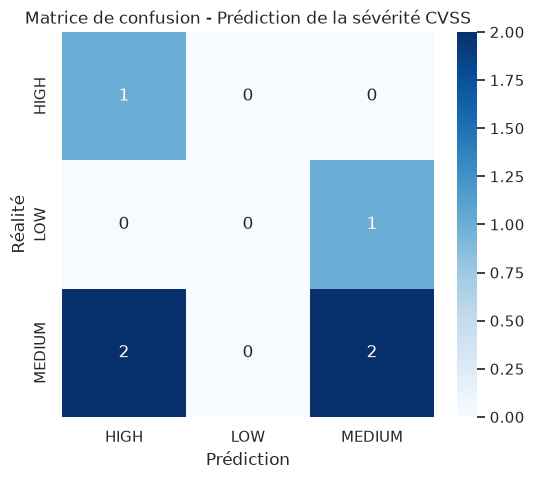

In [26]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion - Prédiction de la sévérité CVSS")
plt.show()


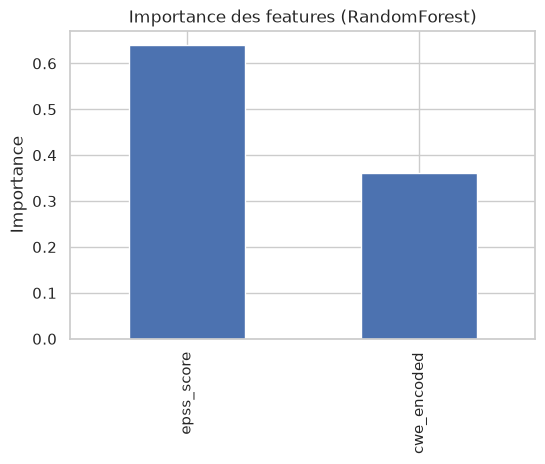

In [27]:
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot.bar(figsize=(6, 4), title="Importance des features (RandomForest)")
plt.ylabel("Importance")
plt.show()


**Validation du modèle supervisé** : on utilise un split train/test
stratifié dont la taille est adaptée à la classe la plus rare pour préserver
au moins un exemple de chaque classe dans le jeu de test, puis on évalue
l'accuracy, la précision/rappel/F1 par classe (classification_report) et la
matrice de confusion. L'importance des features confirme la contribution du
score EPSS et du type de CWE à la prédiction.


## 7. Conclusion

- Les visualisations mettent en évidence les éditeurs et produits les plus
  exposés, ainsi que les types de vulnérabilités (CWE) les plus fréquents.
- Le clustering non supervisé permet de distinguer des profils de risque
  (gravité vs probabilité d'exploitation), utiles pour prioriser les actions
  de remédiation.
- Le modèle supervisé montre qu'il est possible d'estimer la sévérité d'une
  vulnérabilité à partir de l'EPSS et du CWE, avec une performance qui peut
  servir de base à un système d'alerte précoce avant l'attribution complète
  d'un score CVSS.
- Ces résultats alimentent directement la logique de génération d'alertes
  personnalisées du module `src/alerting.py` (cf. Étape 7 du sujet).
